In [2]:
import torch
from utils import solve_riccati
import numpy as np
from network import PhiNetwork, ScoreNetwork
from utils import batched_jacobian
import matplotlib.pyplot as plt

In [3]:
import matplotlib

plt.rc('font', size=14)          # controls default text sizes
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

In [5]:
phi_net_v1 = ScoreNetwork(input_dim=3, out_dim=2, hidden_dim=32)
phi_net_v1.load_state_dict(torch.load('data/phi_network_ip_bsde_nl0.5.pth'))
phi_net_v2 = ScoreNetwork(input_dim=3, out_dim=2, hidden_dim=32)
phi_net_v2.load_state_dict(torch.load('network/phi_network_ip_bsde_nl0.5_v2.pth'))
phi_net_v3 = ScoreNetwork(input_dim=3, out_dim=2, hidden_dim=32)
phi_net_v3.load_state_dict(torch.load('network/phi_network_ip_bsde_nl0.5_v3.pth'))
phi_net_v4 = ScoreNetwork(input_dim=3, out_dim=2, hidden_dim=32)
phi_net_v4.load_state_dict(torch.load('network/phi_network_ip_bsde_nl0.5_terminalweight0101.pth'))
phi_net_v5 = ScoreNetwork(input_dim=3, out_dim=2, hidden_dim=32)
phi_net_v5.load_state_dict(torch.load('network/phi_network_ip_bsde_nl0.5_initialsample50000_initialvar5.0.pth'))

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_59928/3703332711.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  phi_net_v1.load_state_dict(torch.load('data/p

<All keys matched successfully>

In [137]:
theta = torch.load('data/initial_theta_value_IP_nl0.5_exp10000.pth')
autograd_theta = torch.load('data/initial_theta_grad_IP_nl0.5_exp10000.pth')

/var/folders/pd/hp6m3j2j5v9bd6w64h7wl3rm0000gn/T/ipykernel_59928/4113177241.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  theta = torch.load('data/initial_theta_value_

In [138]:
theta.shape, autograd_theta.shape ## initial theta 10000, for each theta rollout 5000 trajectories

(torch.Size([10000, 2]), torch.Size([10000, 10000, 2]))

In [139]:
phi_grads_v1 = phi_net_v1(theta, torch.tensor(0.0).repeat(theta.shape[0], 1)).detach().numpy()
phi_grads_v2 = phi_net_v2(theta, torch.tensor(0.0).repeat(theta.shape[0], 1)).detach().numpy()
phi_grads_v3 = phi_net_v3(theta, torch.tensor(0.0).repeat(theta.shape[0], 1)).detach().numpy()
phi_grads_v4 = phi_net_v4(theta, torch.tensor(0.0).repeat(theta.shape[0], 1)).detach().numpy()
phi_grads_v5 = phi_net_v5(theta, torch.tensor(0.0).repeat(theta.shape[0], 1)).detach().numpy()

In [140]:
mean_grad = autograd_theta.mean(dim=0).numpy()

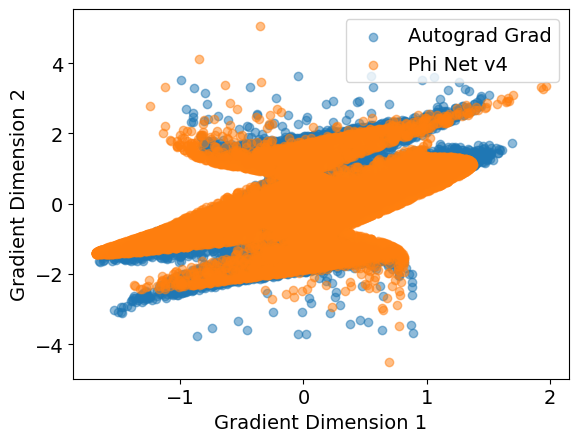

In [151]:
plt.figure()
plt.scatter(mean_grad[:,0], mean_grad[:,1], label='Autograd Grad', alpha=0.5)
# plt.scatter(phi_grads_v1[:,0], phi_grads_v1[:,1], label='Phi Net v1', alpha=0.5)
# plt.scatter(phi_grads_v2[:,0], phi_grads_v2[:,1], label='Phi Net v2', alpha=0.5)
# plt.scatter(phi_grads_v3[:,0], phi_grads_v3[:,1], label='Phi Net v3', alpha=0.5)
plt.scatter(phi_grads_v4[:,0], phi_grads_v4[:,1], label='Phi Net v4', alpha=0.5)
# plt.scatter(phi_grads_v5[:,0], phi_grads_v5[:,1], label='Phi Net v5', alpha=0.5)
plt.xlabel('Gradient Dimension 1')
plt.ylabel('Gradient Dimension 2')
plt.legend()

In [174]:
idx=np.random.randint(0, phi_grads_v1.shape[0])
one_phi_grad_v1 = phi_grads_v1[idx]
one_phi_grad_v2 = phi_grads_v2[idx]
one_phi_grad_v3 = phi_grads_v3[idx]
one_phi_grad_v4 = phi_grads_v4[idx]
one_phi_grad_v5 = phi_grads_v5[idx]
one_autograd = autograd_theta[:,idx,:].numpy()
mean_autograd = one_autograd.mean(axis=0)

In [175]:
one_autograd.shape

(10000, 2)

In [176]:
e1 = ((mean_autograd - one_phi_grad_v1)**2).sum()**0.5
e2 = ((mean_autograd - one_phi_grad_v2)**2).sum()**0.5
e3 = ((mean_autograd - one_phi_grad_v3)**2).sum()**0.5
e4 = ((mean_autograd - one_phi_grad_v4)**2).sum()**0.5
e5 = ((mean_autograd - one_phi_grad_v5)**2).sum()**0.5

In [177]:
e1, e2, e3, e4, e5

(0.36508493885266874,
 0.1877569980460025,
 0.15539057529768957,
 0.23319123459859234,
 0.5493097330323828)

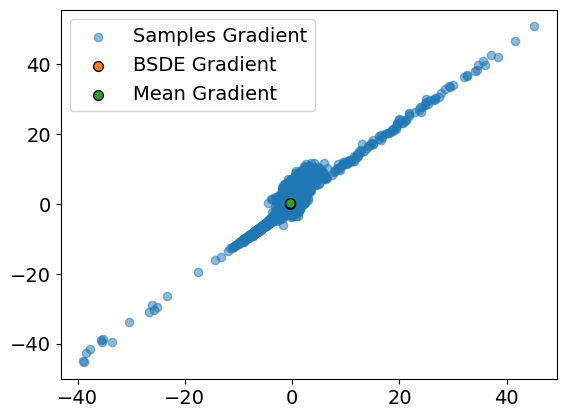

In [178]:
plt.figure()

# samples
plt.scatter(one_autograd[:,0], one_autograd[:,1], alpha=0.5, label='Samples Gradient')

# BSDE gradient (single point)
plt.scatter(
    one_phi_grad_v4[0],
    one_phi_grad_v4[1], edgecolors='k', linewidths=1,
    label='BSDE Gradient', zorder=5, s=50
)

# mean gradient (single point)
plt.scatter(
    mean_autograd[0], mean_autograd[1],
    edgecolors='k', linewidths=1,
    label='Mean Gradient', zorder=6, s=50
)

plt.legend()
# plt.savefig("gradient_plot.pdf", dpi=300, bbox_inches="tight")